# Projekt: Analiza Tekstu i Redukcja Wymiarów (Zadania 1 i 2)
Ten notebook zawiera kompletne rozwiązanie dla Zadania 1 (Wektoryzacja tekstu za pomocą `sentence-transformers`) oraz Zadania 2 (Redukcja wymiarów przy użyciu `PCA` i `t-SNE` wraz z wizualizacją).

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

print("Wszystkie biblioteki zaimportowane pomyślnie!")

c:\Users\pawel\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Wszystkie biblioteki zaimportowane pomyślnie!


## Krok 1: Wektoryzacja tekstu (Zadanie 1)
Wczytujemy dane piosenek z lokalizacji `data/processed/songs.csv` i generujemy embeddingi tekstowe dla kolumny `lyrics` przy użyciu modelu `all-MiniLM-L6-v2`.

In [2]:
csv_path = "data/processed/songs.csv"
embeddings_out = "data/processed/embeddings.npy"
labels_out = "data/processed/labels.npy"
outputs_dir = "outputs"

# Upewniamy się, że katalog na wykresy istnieje
os.makedirs(outputs_dir, exist_ok=True)

# Sprawdzenie i awaryjne wczytanie pliku
if not os.path.exists(csv_path):
    if os.path.exists("songs.csv"):
        os.makedirs("data/processed", exist_ok=True)
        import shutil
        shutil.copy("songs.csv", csv_path)
    else:
        raise FileNotFoundError(f"Nie znaleziono pliku {csv_path}!")

print(f"Wczytywanie danych z {csv_path}...")
df = pd.read_csv(csv_path)
print(f"Liczba wierszy: {len(df)}")

print("Inicjalizacja modelu sentence-transformers (all-MiniLM-L6-v2)...")
model = SentenceTransformer("all-MiniLM-L6-v2")

print("Generowanie embeddingów dla kolumny df['lyrics']...")
lyrics_list = df["lyrics"].fillna("").tolist()
embeddings = model.encode(lyrics_list, show_progress_bar=True)

print(f"Kształt wygenerowanej macierzy: {embeddings.shape}")

# Zapis macierzy do plików .npy
np.save(embeddings_out, embeddings)
print(f"Zapisano embeddingi do: {embeddings_out}")

if "mood_label" in df.columns:
    labels = df["mood_label"].dropna().to_numpy()
    np.save(labels_out, labels)
    print(f"Zapisano etykiety nastrojów do: {labels_out}")

Wczytywanie danych z data/processed/songs.csv...
Liczba wierszy: 160
Inicjalizacja modelu sentence-transformers (all-MiniLM-L6-v2)...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4140.28it/s]


Generowanie embeddingów dla kolumny df['lyrics']...


Batches: 100%|██████████| 5/5 [00:03<00:00,  1.52it/s]

Kształt wygenerowanej macierzy: (160, 384)
Zapisano embeddingi do: data/processed/embeddings.npy
Zapisano etykiety nastrojów do: data/processed/labels.npy


## Krok 2: Redukcja wymiarów & Wizualizacja (Zadanie 2)
Dokonujemy redukcji wymiarów za pomocą algorytmów **PCA** oraz **t-SNE** do przestrzeni dwuwymiarowej (2D), a następnie generujemy wymagane wykresy.

Obliczanie PCA -> 2D...
Obliczanie t-SNE -> 2D...


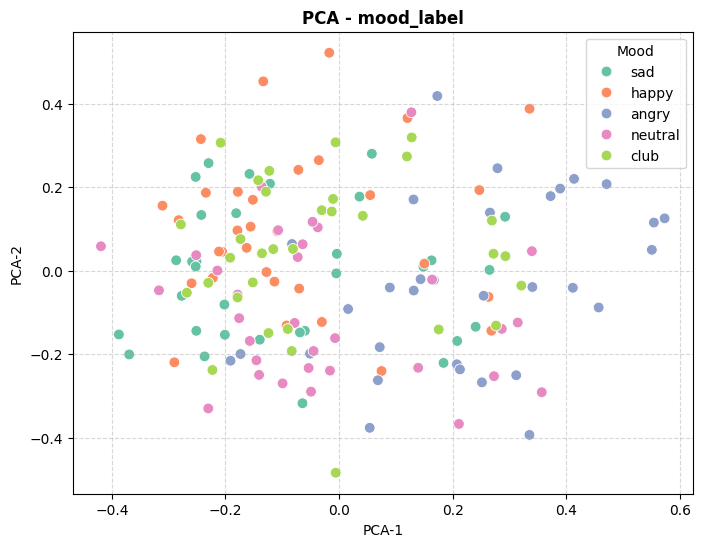

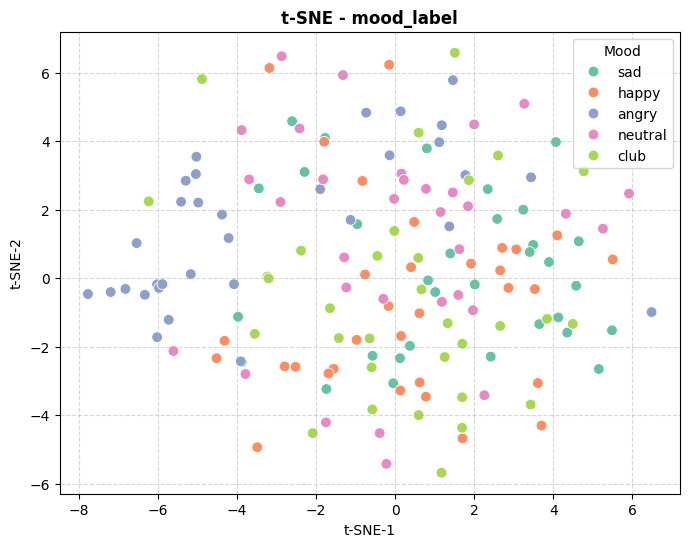

Wykresy zostały wygenerowane i zapisane w folderze 'outputs/'!


In [3]:
# 1. PCA do 2D
print("Obliczanie PCA -> 2D...")
pca = PCA(n_components=2, random_state=42)
pca_results = pca.fit_transform(embeddings)

# 2. t-SNE do 2D
print("Obliczanie t-SNE -> 2D...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_results = tsne.fit_transform(embeddings)

# Przygotowanie danych do wykresu
df_viz = pd.DataFrame({
    "PCA-1": pca_results[:, 0],
    "PCA-2": pca_results[:, 1],
    "t-SNE-1": tsne_results[:, 0],
    "t-SNE-2": tsne_results[:, 1],
    "Mood": df["mood_label"]
})

# Definicja mapy kolorów
moods = ["sad", "happy", "angry", "neutral", "club"]
palette = sns.color_palette("Set2", len(moods))
color_map = dict(zip(moods, palette))

# Generowanie i zapisywanie pojedynczego wykresu PCA
fig_pca, ax_pca = plt.subplots(figsize=(8, 6))
sns.scatterplot(x="PCA-1", y="PCA-2", hue="Mood", data=df_viz, palette=color_map, ax=ax_pca, s=60)
ax_pca.set_title("PCA - mood_label", fontsize=12, fontweight="bold")
ax_pca.grid(True, linestyle="--", alpha=0.5)
pca_img_path = os.path.join(outputs_dir, "pca_mood.png")
plt.savefig(pca_img_path, dpi=300)
plt.show()

# Generowanie i zapisywanie pojedynczego wykresu t-SNE
fig_tsne, ax_tsne = plt.subplots(figsize=(8, 6))
sns.scatterplot(x="t-SNE-1", y="t-SNE-2", hue="Mood", data=df_viz, palette=color_map, ax=ax_tsne, s=60)
ax_tsne.set_title("t-SNE - mood_label", fontsize=12, fontweight="bold")
ax_tsne.grid(True, linestyle="--", alpha=0.5)
tsne_img_path = os.path.join(outputs_dir, "tsne_mood.png")
plt.savefig(tsne_img_path, dpi=300)
plt.show()

print("Wykresy zostały wygenerowane i zapisane w folderze 'outputs/'!")

## Krok 3: Analiza i wybór optymalnej liczby klastrów

In [4]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score
from sklearn.neighbors import NearestNeighbors
from typing import Any
from numpy.typing import NDArray
import numpy as np

print("\n--- Starting Step 3 and 4 ---")

# Fallback data loading from Step 1 (if running in a separate cell/script)
embeddings = np.load("data/processed/embeddings.npy")
image_labels = np.load("data/processed/labels.npy", allow_pickle=True)

## Step 3: Analysis and selection of the optimal number of clusters
print("Searching for the optimal number of clusters...")

def find_optimal_clusters(embeddings: NDArray, max_clusters: int = 10, random_state=42):
    max_clusters = min(max_clusters, len(embeddings) - 1)
    range_n_clusters = list(range(2, max_clusters + 1))
    
    inertia_values = []
    silhouette_values = []
    davies_bouldin_values = []

    for n_clusters in range_n_clusters:
        kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
        cluster_labels = kmeans.fit_predict(embeddings)

        inertia_values.append(kmeans.inertia_)
        if len(np.unique(cluster_labels)) > 1:
            silhouette_values.append(silhouette_score(embeddings, cluster_labels))
        else:
            silhouette_values.append(0)
        davies_bouldin_values.append(davies_bouldin_score(embeddings, cluster_labels))

    optimal_k = {}
    inertia_diffs = np.diff(inertia_values)
    inertia_diffs2 = np.diff(inertia_diffs)
    optimal_k['elbow'] = range_n_clusters[np.argmin(inertia_diffs2) + 1]
    optimal_k['silhouette'] = range_n_clusters[np.argmax(silhouette_values)]
    optimal_k['davies_bouldin'] = range_n_clusters[np.argmin(davies_bouldin_values)]

    fig = make_subplots(
        rows=3, cols=1,
        subplot_titles=(
            "Elbow Method (Inertia)",
            "Silhouette Score (higher is better)",
            "Davies-Bouldin Index (lower is better)"
        ),
        vertical_spacing=0.15
    )

    # 1. Elbow
    fig.add_trace(go.Scatter(x=range_n_clusters, y=inertia_values, mode='lines+markers', name='Inertia', line=dict(color='blue')), row=1, col=1)
    # 2. Silhouette
    fig.add_trace(go.Scatter(x=range_n_clusters, y=silhouette_values, mode='lines+markers', name='Silhouette Score', line=dict(color='green')), row=2, col=1)
    # 3. Davies-Bouldin
    fig.add_trace(go.Scatter(x=range_n_clusters, y=davies_bouldin_values, mode='lines+markers', name='Davies-Bouldin Index', line=dict(color='purple')), row=3, col=1)

    fig.update_layout(title='Evaluation of optimal number of clusters', height=800, width=900)
    return fig, optimal_k

# Display the analysis plot for elbow method etc. (you can use max_clusters=15)
fig_optimal, optimal_k = find_optimal_clusters(embeddings, max_clusters=15)
fig_optimal.show()
print(f"Suggested optimal number of clusters: {optimal_k}")

# We know the true number of moods (5: sad, happy, angry, neutral, club), 
# so for evaluation we will force the split into 5 clusters (or the optimal number chosen by you).
TRUE_K = len(np.unique(image_labels))
print(f"\nUnique classes (moods) in the dataset: {TRUE_K}")


--- Starting Step 3 and 4 ---
Searching for the optimal number of clusters...


Suggested optimal number of clusters: {'elbow': 14, 'silhouette': 2, 'davies_bouldin': 13}

Unique classes (moods) in the dataset: 5


## Krok 4: Klastrowanie wieloma algorytmami i Ewaluacja (Adjusted Rand Score)

In [6]:
import pandas as pd
from sklearn.manifold import TSNE

# Load original CSV to get 'title' and 'artist' columns
df_songs = pd.read_csv("data/processed/songs.csv")

def cluster_embeddings(embeddings: NDArray, algorithm_name: str, **kwargs):
    if algorithm_name == 'GaussianMixture':
        model = GaussianMixture(**kwargs)
        model.fit(embeddings)
        labels = model.predict(embeddings)
    elif algorithm_name == 'KMeans':
        model = KMeans(**kwargs)
        labels = model.fit_predict(embeddings)
    elif algorithm_name == 'AgglomerativeClustering':
        model = AgglomerativeClustering(**kwargs)
        labels = model.fit_predict(embeddings)
    else:
        raise ValueError("Unsupported algorithm in this example")
    return labels, model

# 1. KMeans
labels_kmeans, _ = cluster_embeddings(embeddings, 'KMeans', n_clusters=TRUE_K, random_state=42, n_init=10)
ari_kmeans = adjusted_rand_score(image_labels, labels_kmeans)

# 2. Gaussian Mixture Model (GMM)
labels_gmm, _ = cluster_embeddings(embeddings, 'GaussianMixture', n_components=TRUE_K, random_state=42)
ari_gmm = adjusted_rand_score(image_labels, labels_gmm)

# 3. Agglomerative Clustering (Hierarchical)
labels_agg, _ = cluster_embeddings(embeddings, 'AgglomerativeClustering', n_clusters=TRUE_K, linkage='ward')
ari_agg = adjusted_rand_score(image_labels, labels_agg)

print("\n--- Evaluation Results (Adjusted Rand Score) ---")
print(f"KMeans ARI:                  {ari_kmeans:.4f}")
print(f"Gaussian Mixture ARI:        {ari_gmm:.4f}")
print(f"Agglomerative Clustering ARI: {ari_agg:.4f}")

## Interactive Visualization of the best model using Plotly
def plot_embeddings(
    embeddings: NDArray, 
    clustering_results, 
    symbol: str, 
    color: str, 
    classes: list, 
    titles: list,
    artists: list,
    reduction_technique: str = "tsne"
):
    # Using t-SNE for dimensionality reduction for visualization
    transformer = TSNE(n_components=2, random_state=42, perplexity=30)
    reduced = transformer.fit_transform(embeddings)
    
    clustering_results = list(map(str, clustering_results))
    
    df = pd.DataFrame({
        "x": reduced[:, 0],
        "y": reduced[:, 1],
        "True_Mood": classes,
        "Cluster_ID": clustering_results,
        "Artist": artists,
        "Title": titles
    })
    
    df = df.astype({"True_Mood": "category", "Cluster_ID": "category"})
    title = f"Clusters Visualization (KMeans) - {reduction_technique.upper()} Reduction"
    
    fig = px.scatter(
        df, x="x", y="y",
        color="Cluster_ID",         # Color represents the assigned cluster
        symbol="True_Mood",         # Marker shape represents the true mood from CSV
        title=title, 
        # Customize hover data: disable X and Y, enable Artist, Title, Mood and Cluster
        hover_data={
            "x": False,
            "y": False,
            "Artist": True,
            "Title": True,
            "True_Mood": True,
            "Cluster_ID": True
        },
        color_discrete_sequence=px.colors.qualitative.Set2
    )
    fig.update_traces(marker=dict(size=9, opacity=0.8))
    fig.update_layout(template="plotly_white")
    fig.show()

print("\nGenerating an interactive plot for the KMeans model...")
plot_embeddings(
    embeddings=embeddings,
    clustering_results=labels_kmeans,
    symbol="True_Mood",
    color="Cluster_ID",
    classes=image_labels,
    titles=df_songs["title"].tolist(),    # Fetching titles
    artists=df_songs["artist"].tolist(),  # Fetching artists
    reduction_technique="tsne"
)


--- Evaluation Results (Adjusted Rand Score) ---
KMeans ARI:                  0.1056
Gaussian Mixture ARI:        0.0785
Agglomerative Clustering ARI: 0.0634

Generating an interactive plot for the KMeans model...
